In [1]:
from elpv_dataset.utils import load_dataset
images, proba, types = load_dataset()

# aktivasi gpu

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from elpv_dataset.utils import load_dataset

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # GPU:0 (NVIDIA) dan aktifkan memory growth
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"Menggunakan Device: {gpus[0]}")
    except RuntimeError as e:
        print(f"GPU Config Error: {e}")

Menggunakan Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# data preparation

In [ ]:
print("\nMemuat ELPV Dataset...")
images, proba, types = load_dataset()

# Normalisasi: Grayscale 0-255 menjadi 0.0-1.0
images = images.astype('float32') / 255.0

# Tambahkan dimensi channel (TensorFlow perlu pake format NHWC: Batch, Height, Width, Channel)
images = np.expand_dims(images, axis=-1) 

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    images, proba, test_size=0.2, random_state=42
)

print(f"Data Train: {X_train.shape}")
print(f"Data Test: {X_test.shape}")


[1/4] Memuat ELPV Dataset...
Data Train: (2099, 300, 300, 1)
Data Test: (525, 300, 300, 1)


In [ ]:
with tf.device('/GPU:0'):
    model = tf.keras.Sequential([
        # Layer Konvolusi 1
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(300, 300, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Layer Konvolusi 2
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Layer Konvolusi 3
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Flatten & Dense
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5), # Mencegah overfitting pasangin dropout
        
        # Output: 1 neuron (Regresi nilai probabilitas 0.0 - 1.0)
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='mse', # Mean Squared Error cocok untuk nilai probabilitas kontinu
        metrics=['mae']
    )

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 298, 298, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 149, 149, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 147, 147, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 73, 73, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 71, 71, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 35, 35, 128)      0

In [ ]:
print("\nMemulai Training di GTX 1050...")
# Batch size 32 aman untuk VRAM 3-4GB pada gambar 300x300
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


[3/4] Memulai Training di GTX 1050...
Epoch 1/15
66/66 [==============================] - 57s 394ms/step - loss: 0.1887 - mae: 0.3582 - val_loss: 0.1524 - val_mae: 0.3138
Epoch 2/15
66/66 [==============================] - 45s 537ms/step - loss: 0.1499 - mae: 0.3179 - val_loss: 0.1406 - val_mae: 0.3297
Epoch 3/15
66/66 [==============================] - 27s 414ms/step - loss: 0.1403 - mae: 0.2998 - val_loss: 0.1314 - val_mae: 0.2989
Epoch 4/15
66/66 [==============================] - 27s 406ms/step - loss: 0.1382 - mae: 0.2881 - val_loss: 0.1271 - val_mae: 0.3012
Epoch 5/15
66/66 [==============================] - 30s 451ms/step - loss: 0.1313 - mae: 0.2844 - val_loss: 0.1317 - val_mae: 0.2572
Epoch 6/15
66/66 [==============================] - 30s 449ms/step - loss: 0.1268 - mae: 0.2666 - val_loss: 0.1238 - val_mae: 0.2738
Epoch 7/15
66/66 [==============================] - 27s 410ms/step - loss: 0.1233 - mae: 0.2679 - val_loss: 0.1199 - val_mae: 0.2786
Epoch 8/15
66/66 [============


[4/4] Selesai! Menampilkan Grafik Performa...


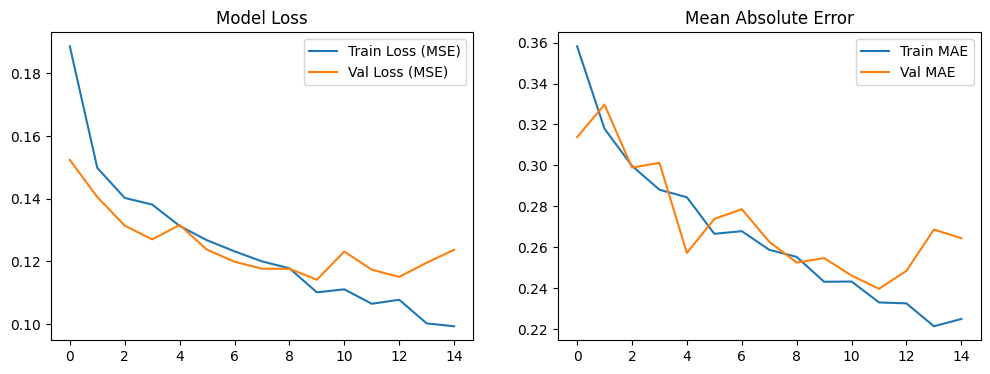

In [ ]:
print("\nMenampilkan Grafik Performa...")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.legend()

plt.show()

In [7]:
# Mengambil 5 sampel data test untuk uji prediksi
prediksi_mentah = model.predict(X_test[:5])

for i, pred in enumerate(prediksi_mentah):
    print(f"Gambar {i+1} -> Nilai Prediksi Cacat: {pred[0]:.3f} (Nilai Asli: {y_test[i]})")

1/1 [==============================] - 6s 6s/step
Gambar 1 -> Nilai Prediksi Cacat: 0.439 (Nilai Asli: 1.0)
Gambar 2 -> Nilai Prediksi Cacat: 0.053 (Nilai Asli: 0.3333333333333333)
Gambar 3 -> Nilai Prediksi Cacat: 0.306 (Nilai Asli: 0.0)
Gambar 4 -> Nilai Prediksi Cacat: 0.999 (Nilai Asli: 1.0)
Gambar 5 -> Nilai Prediksi Cacat: 0.213 (Nilai Asli: 0.0)


In [8]:
def bulatkan_ke_label_elpv(nilai_prediksi):
    # Standar nilai probabilitas di dataset ELPV
    label_standar = np.array([0.0, 0.33, 0.67, 1.0])
    
    # Cari nilai di label_standar yang selisihnya paling kecil dengan nilai_prediksi
    idx = (np.abs(label_standar - nilai_prediksi)).argmin()
    return label_standar[idx]

# Contoh implementasi untuk hasil prediksi
prediksi_mentah = model.predict(X_test[:5])

print("\nHasil Setelah Dibulatkan ke Standar ELPV:")
for i, pred in enumerate(prediksi_mentah):
    nilai_bulat = bulatkan_ke_label_elpv(pred[0])
    print(f"Gambar {i+1} -> Prediksi: {nilai_bulat} | Asli: {y_test[i]}")

1/1 [==============================] - 0s 104ms/step

Hasil Setelah Dibulatkan ke Standar ELPV:
Gambar 1 -> Prediksi: 0.33 | Asli: 1.0
Gambar 2 -> Prediksi: 0.0 | Asli: 0.3333333333333333
Gambar 3 -> Prediksi: 0.33 | Asli: 0.0
Gambar 4 -> Prediksi: 1.0 | Asli: 1.0
Gambar 5 -> Prediksi: 0.33 | Asli: 0.0


In [9]:
import matplotlib.pyplot as plt
import numpy as np

def bulatkan_ke_label_elpv(nilai_prediksi):
    # Standar nilai probabilitas di dataset ELPV
    label_standar = np.array([0.0, 0.33, 0.67, 1.0])
    idx = (np.abs(label_standar - nilai_prediksi)).argmin()
    return label_standar[idx]

def visualisasikan_prediksi_grid(X_data, y_true, model, rows=6, cols=6):
    # 1. Ambil sampel secara acak dari data test
    jumlah_sampel = rows * cols
    indeks_acak = np.random.choice(len(X_data), jumlah_sampel, replace=False)
    
    X_sampel = X_data[indeks_acak]
    y_sampel_asli = y_true[indeks_acak]
    
    # 2. Lakukan prediksi menggunakan GPU kamu
    y_sampel_prediksi = model.predict(X_sampel, verbose=0)
    
    # 3. Setup ukuran plot grid (seperti contoh gambar ulat sawi)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    axes = axes.ravel() # Meratakan matriks axes menjadi array 1D
    
    for i in range(jumlah_sampel):
        # Tampilkan gambar (karena grayscale, squeeze dimensi channel terakhir)
        axes[i].imshow(X_sampel[i].squeeze(), cmap='gray')
        axes[i].axis('off') # Hilangkan angka koordinat x dan yAxis
        
        # Ambil nilai kontinu dan nilai bulatnya
        pred_kontinu = y_sampel_prediksi[i][0]
        pred_bulat = bulatkan_ke_label_elpv(pred_kontinu)
        asli = y_sampel_asli[i]
        
        # Tentukan teks judul di atas gambar
        title_text = f"L: {asli:.2f}\nP: {pred_kontinu:.2f} ({pred_bulat:.2f})"
        
        # Logika warna teks: Jika hasil pembulatan sama dengan nilai asli, kasih warna hijau
        # Toleransi kecil karena floating point
        if np.isclose(pred_bulat, asli, atol=0.01):
            text_color = 'green'
        else:
            text_color = 'red'
            
        axes[i].set_title(title_text, fontsize=9, color=text_color, pad=8)
        
    plt.tight_layout()
    plt.show()

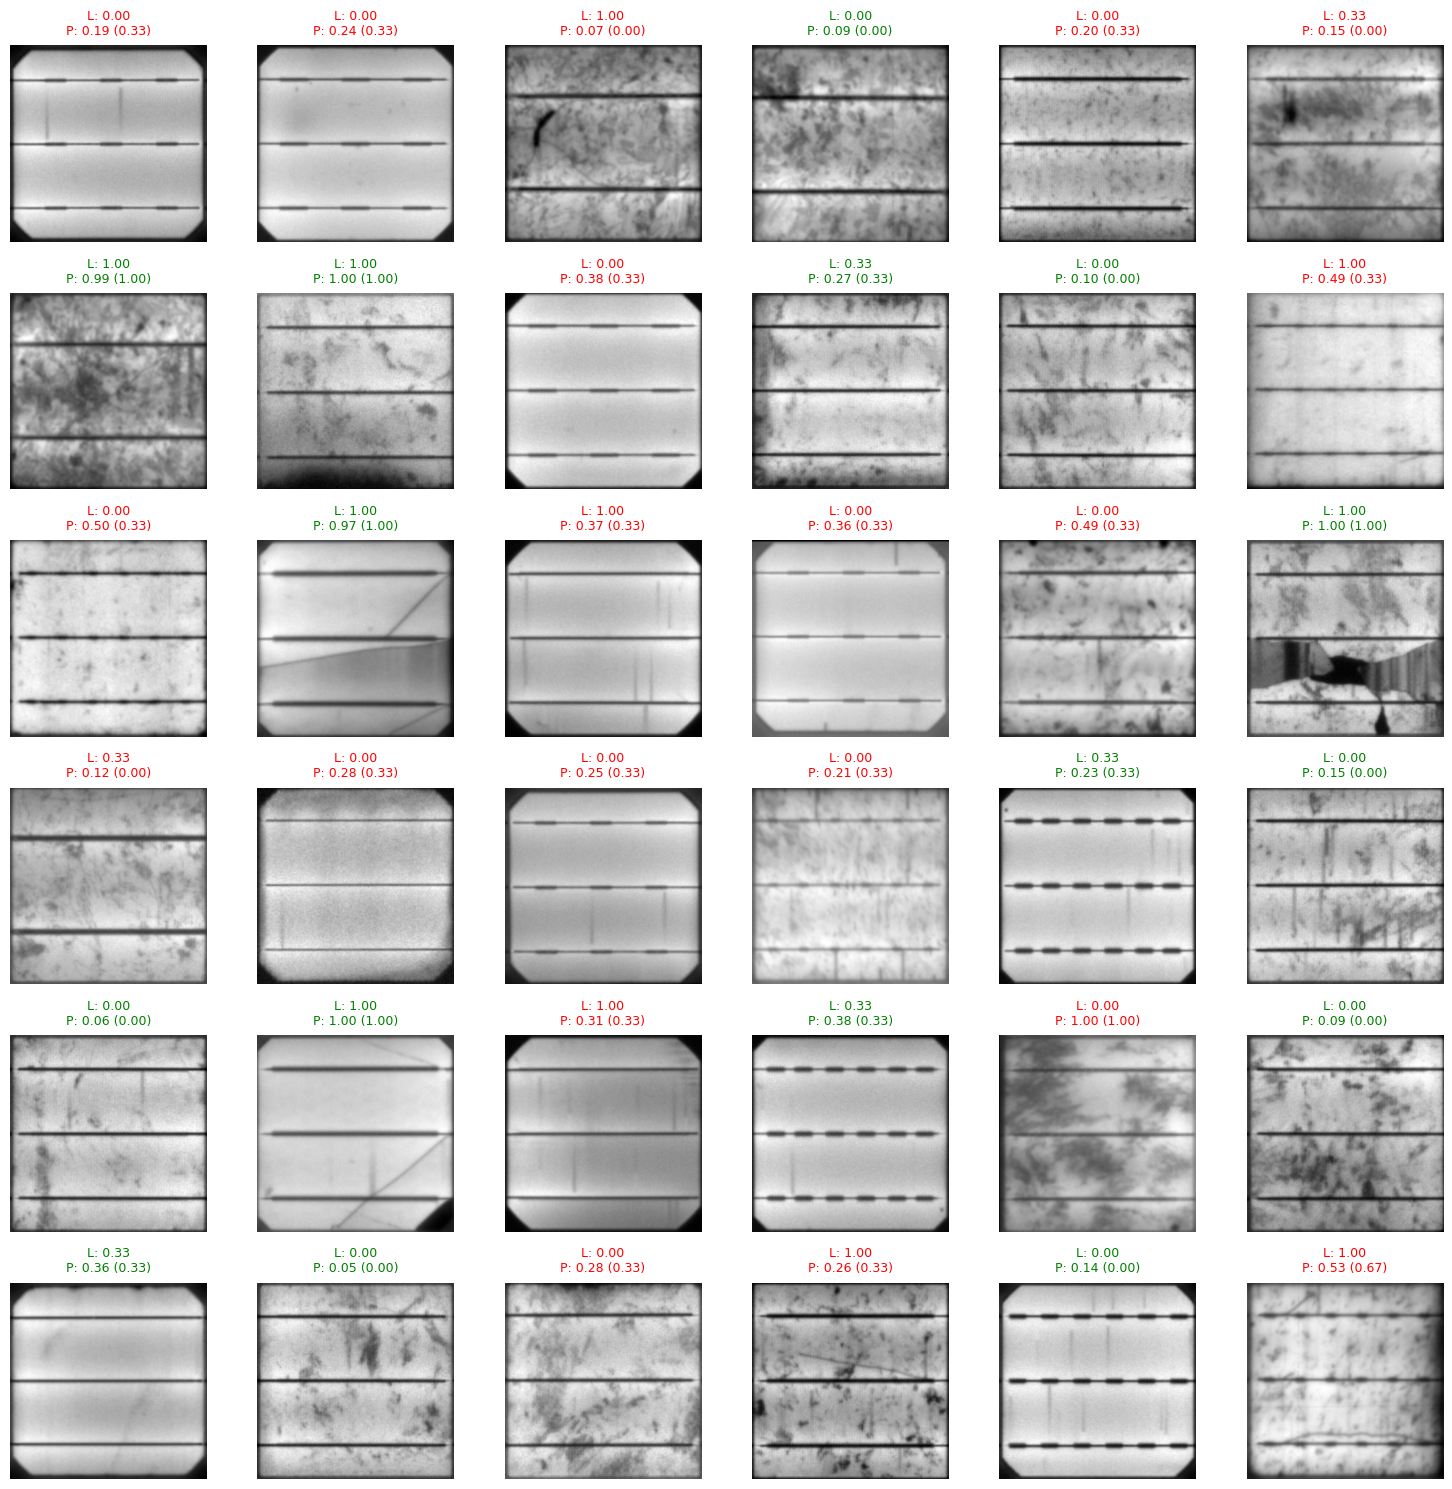

In [10]:
visualisasikan_prediksi_grid(X_test, y_test, model, rows=6, cols=6)

Note:

misal elemen 1,1

L = 0.0 ini adalah hasil labeling dari actual value

P = 0.19 (0.33), maksudnya adalah dari hasil cnn model kita peroleh 0.19 dan karena default nilai dataset itu hanya 0, 0.33, 0.67, dan 1 jadi 0.19 itu lebih mendekati 0.33 jadi di diklasifikasikan kedalam 0.33

====================================================================================================

Ensiklopedia data:

0 : Fully Functional Solar Cell (normal)
Solar cell normal terlihat secara gambar/optically. Arus listrik bisa mengalir lancar di seluruh permukaan sel, sehingga gambar EL terlihat terang merata tanpa ada garis hitam atau area gelap/anomali

0.33 : Slightly Defective Solar Cell (sedikit cacat) atau micro craks 
Di kelas ini, solar cell mulai ada sedikit cacat berupa micro cracks atau ada defek di material sehingga efisiensi quantum akan sedikti menurun

0.67 : Moderately Defective Solar Cell (cukup cacat)
Di kelas ini, kerusakan sudah terlihat jelas. Ada area gelap yang terlihat akibat pemutusan jalur listrik/arus mengalir (Finger Failure -> retakan sudah lebar ke hampir sebagian sel surya) 

1.0 : Severely Defective Solar Cell (parah cacat)
Di kelas ini, kerusakannya seperti retakannya sudah sangat parah sehingga hampir kesulurahn sel surya banyak sekali area gelap. Quantum Efficiency hampir nol dan listrik tidak mengalirkan sehingga tidak mengeluarkan output daya sama sekali 